# Workshop 1: **Logistic and Softmax Regression**

In this practical, we will write Python code to tackle a real-world classification problem using the Iris dataset. The primary goal of the Iris flower dataset is to build a machine learning model that accurately classifies an iris flower into one of three species (Setosa, Versicolor, or Virginica) based on its physical measurements. It consists of 150 samples of iris flowers, with 50 samples each from the Iris setosa, Iris virginica, and Iris versicolor species. For each flower, four features were measured in centimeters: sepal length, sepal width, petal length, and petal width.

We will use softmax regression, the multiclass extension of logistic regression, trained using gradient descent.
Both logistic regression (binary) and softmax regression (multiclass) can be interpreted as single-layer neural models consisting of a linear transformation followed by a nonlinear activation function.

Gradient descent serves as the core optimisation mechanism behind backpropagation, the fundamental learning algorithm used in modern deep learning models for computer vision and natural language processing (NLP).


Iris Dataset:
https://www.kaggle.com/datasets/uciml/iris

Demo: https://uclaacm.github.io/gradient-descent-visualiser/#playground

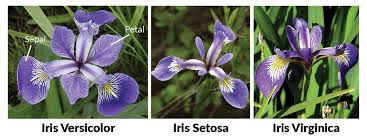

# Code for a model with two input features and three classes

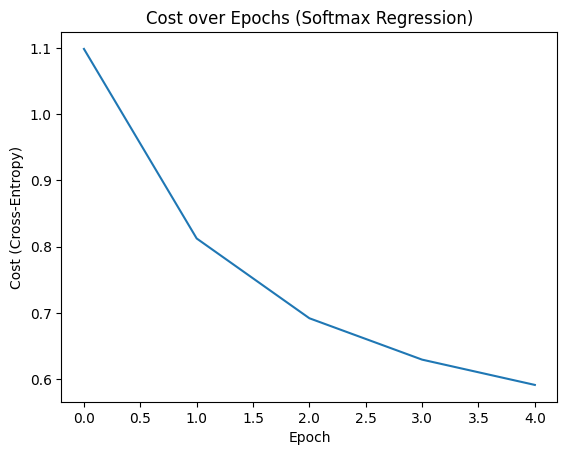

Accuracy: 0.7333

Confusion Matrix:
[[10  0  0]
 [ 1  3  6]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.75      0.30      0.43        10
   virginica       0.60      0.90      0.72        10

    accuracy                           0.73        30
   macro avg       0.75      0.73      0.70        30
weighted avg       0.75      0.73      0.70        30



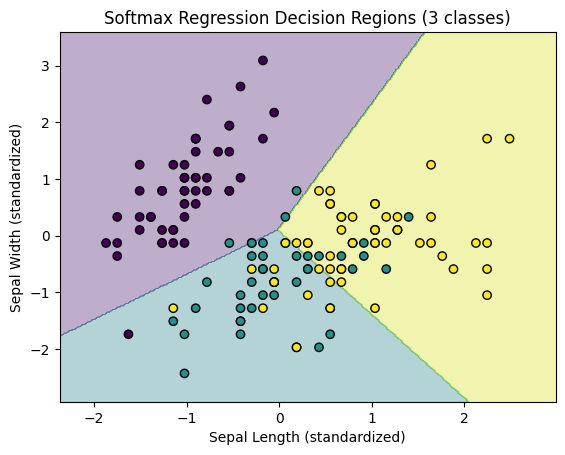

In [8]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# 1) Load full Iris (3 classes)
# -----------------------------
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target  # 0,1,2

# Use TWO features
X = df[["sepal length (cm)", "sepal width (cm)"]].values
y = df["target"].values
K = len(np.unique(y))  # number of classes (3)

# -----------------------------
# 2) Standardize features
# -----------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Add bias term
X_bias = np.hstack([np.ones((X.shape[0], 1)), X])  # (N, D+1)

# -----------------------------
# 3) Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_bias, y, test_size=0.2, random_state=42, stratify=y
)

m, D = X_train.shape  # m examples, D features (incl. bias)

# One-hot encode y_train for softmax cross-entropy
Y_train = np.zeros((m, K))
Y_train[np.arange(m), y_train] = 1  # (m, K)

# -----------------------------
# 4) Softmax Regression (GD)
# -----------------------------
def softmax(z):
    # z: (m, K)
    z = z - np.max(z, axis=1, keepdims=True)  # stability
    expz = np.exp(z)
    return expz / np.sum(expz, axis=1, keepdims=True)

learning_rate = 1
n_iterations = 5

# Theta: (D, K)
Theta = np.zeros((D, K))

cost_values = []

for epoch in range(n_iterations):
    scores = X_train @ Theta          # (m, K)
    probs = softmax(scores)           # (m, K)

    # Gradient of cross-entropy softmax loss
    grad = (1 / m) * (X_train.T @ (probs - Y_train))  # (D, K)

    # Update
    Theta -= learning_rate * grad

    # Loss (cross-entropy)
    eps = 1e-12
    loss = -(1 / m) * np.sum(Y_train * np.log(probs + eps))
    cost_values.append(loss)

# Plot loss
plt.plot(range(n_iterations), cost_values)
plt.xlabel("Epoch")
plt.ylabel("Cost (Cross-Entropy)")
plt.title("Cost over Epochs (Softmax Regression)")
plt.show()

# -----------------------------
# 5) Evaluate on test set
# -----------------------------
test_probs = softmax(X_test @ Theta)
y_test_pred = np.argmax(test_probs, axis=1)

accuracy = np.mean(y_test_pred == y_test)
print(f"Accuracy: {accuracy:.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=data.target_names))

# -----------------------------
# 6) Visualize decision regions (2D)
# -----------------------------
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]            # (G, 2) in standardized space
grid_bias = np.hstack([np.ones((grid.shape[0], 1)), grid])  # (G, 3)

grid_probs = softmax(grid_bias @ Theta)         # (G, K)
Z = np.argmax(grid_probs, axis=1).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.35)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
plt.title("Softmax Regression Decision Regions (3 classes)")
plt.xlabel("Sepal Length (standardized)")
plt.ylabel("Sepal Width (standardized)")
plt.show()


# Code for a model with four input features and three classes

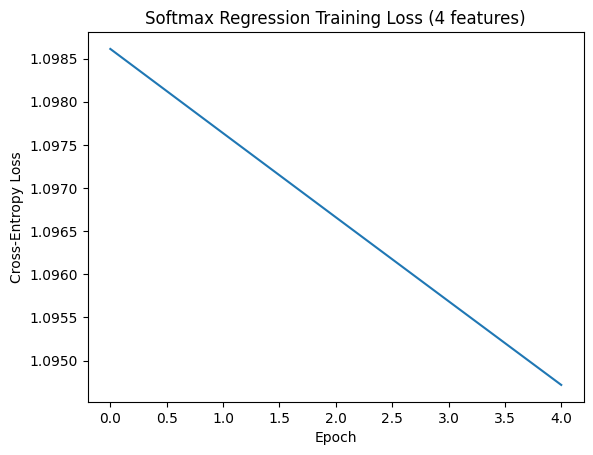

Test accuracy: 0.7667

Confusion matrix:
[[10  0  0]
 [ 0  3  7]
 [ 0  0 10]]

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.30      0.46        10
   virginica       0.59      1.00      0.74        10

    accuracy                           0.77        30
   macro avg       0.86      0.77      0.73        30
weighted avg       0.86      0.77      0.73        30



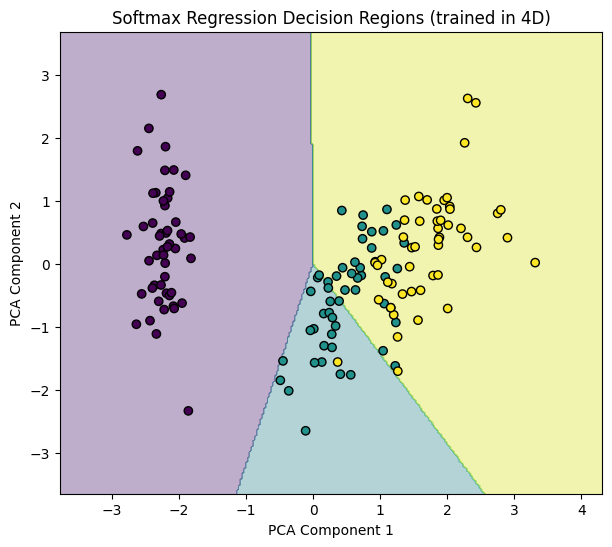

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# 1) Load full Iris (3 classes) + ALL 4 features
# -----------------------------
data = load_iris()
X = data.data              # shape (150, 4)
y = data.target            # 0,1,2
K = len(np.unique(y))      # 3 classes

# -----------------------------
# 2) Standardize features
# -----------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Add bias term
X_bias = np.hstack([np.ones((X.shape[0], 1)), X])  # (N, 5)

# -----------------------------
# 3) Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_bias, y, test_size=0.2, random_state=42, stratify=y
)

m, D = X_train.shape  # D = 5 (bias + 4 features)

# One-hot encode labels for softmax CE
Y_train = np.zeros((m, K))
Y_train[np.arange(m), y_train] = 1

# -----------------------------
# 4) Softmax Regression (GD)
# -----------------------------
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)  # numerical stability
    expz = np.exp(z)
    return expz / np.sum(expz, axis=1, keepdims=True)

learning_rate = 0.001
n_epochs = 5

Theta = np.zeros((D, K))   # (5, 3)
loss_history = []

for epoch in range(n_epochs):
    scores = X_train @ Theta          # (m, K)
    probs = softmax(scores)           # (m, K)

    grad = (1 / m) * (X_train.T @ (probs - Y_train))  # (D, K)
    Theta -= learning_rate * grad

    eps = 1e-12
    loss = -(1 / m) * np.sum(Y_train * np.log(probs + eps))
    loss_history.append(loss)

# Plot loss curve
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Softmax Regression Training Loss (4 features)")
plt.show()

# -----------------------------
# 5) Evaluate
# -----------------------------
test_probs = softmax(X_test @ Theta)
y_pred = np.argmax(test_probs, axis=1)

acc = np.mean(y_pred == y_test)
print(f"Test accuracy: {acc:.4f}\n")

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

from sklearn.decomposition import PCA

# -----------------------------
# 6) Decision regions via PCA
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)   # project standardized X (no bias)

# Grid in PCA space
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_pca = np.c_[xx.ravel(), yy.ravel()]   # (G, 2)

# Map grid BACK to 4D feature space
grid_4d = pca.inverse_transform(grid_pca)

# Add bias
grid_4d_bias = np.hstack([np.ones((grid_4d.shape[0], 1)), grid_4d])

# Predict
grid_probs = softmax(grid_4d_bias @ Theta)
Z = np.argmax(grid_probs, axis=1).reshape(xx.shape)

# Plot
plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.35)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors="k")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Softmax Regression Decision Regions (trained in 4D)")
plt.show()
